In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.applications import MobileNet, ResNet50, VGG16, InceptionV3
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input
from tensorflow.keras.applications.inception_v3 import preprocess_input as inceptionv3_preprocess_input


from google.colab import drive
from google.colab import files


In [2]:
!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/zw4p9kj6nt-2.zip
!unzip zw4p9kj6nt-2.zip -d /content/dataset
!ls /content/dataset

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/434 - Copy.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/434.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/446 - Copy.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/446.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/447 - Copy.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/447.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/457 - Copy.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/457.jpg  
  inflating: /content/dataset/Mosquito-on-human-skin/data_splitting/Test/aegypti smashed/46 - Copy.jpg  
  inflating: /content/dataset/Mosquito-on-human-

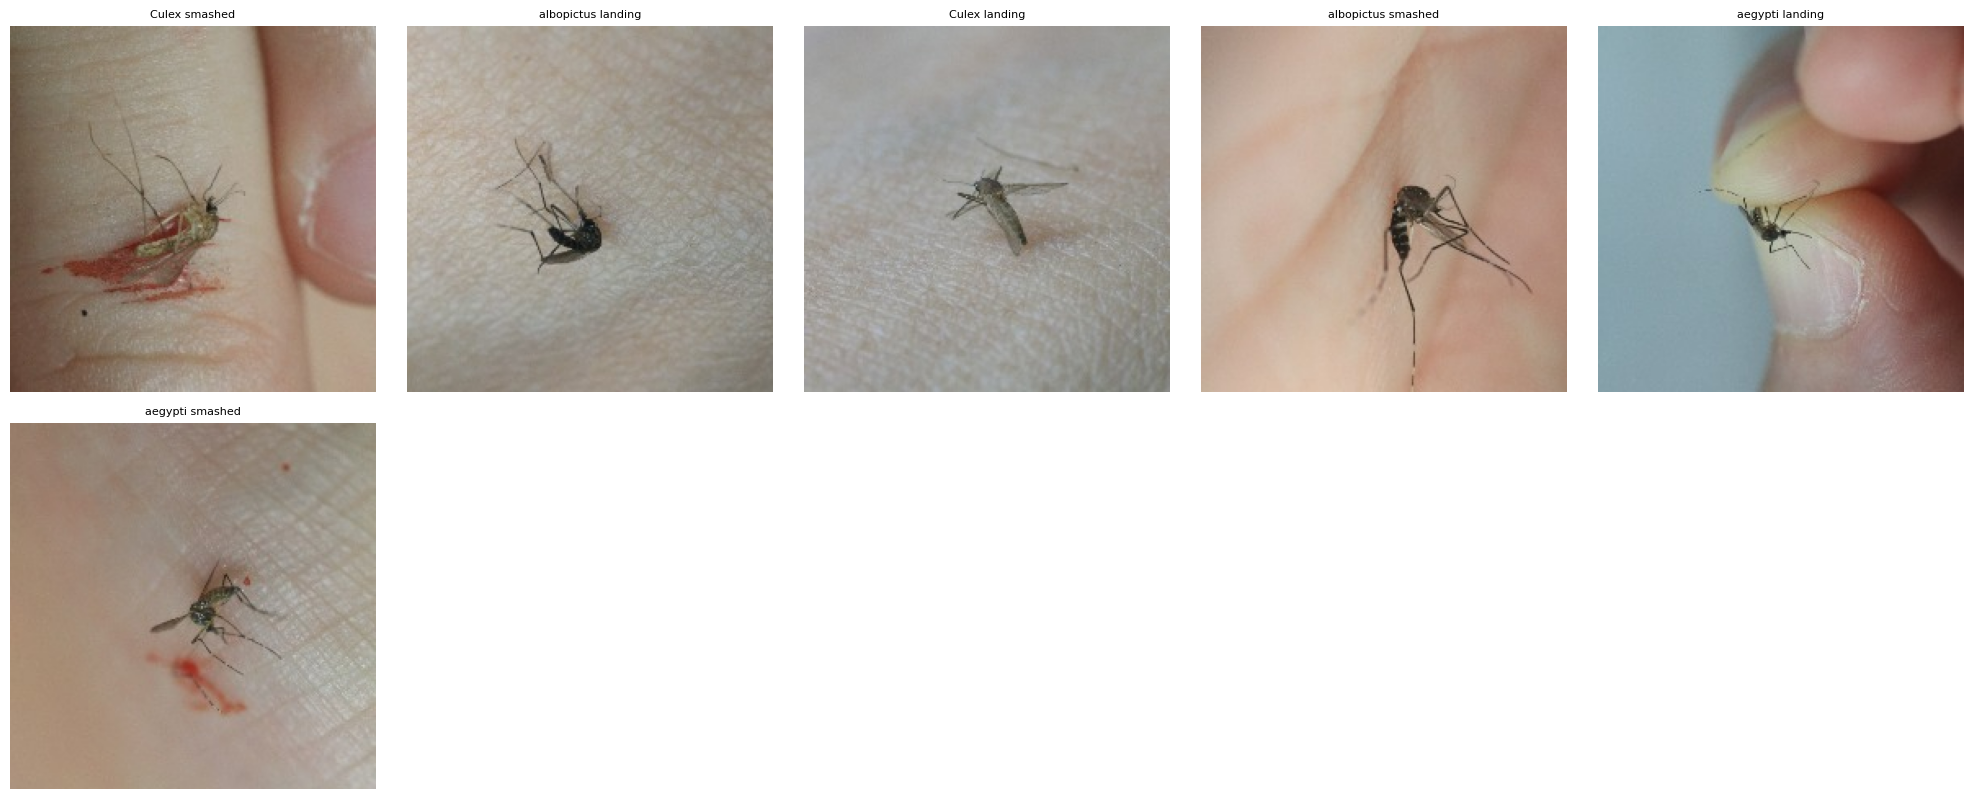

In [3]:
# Set the number of categories
num_class = 6

# Set the drawing size (resize to fit the display)
plt.figure(figsize=(20, 20))

path = '/content/dataset/Mosquito-on-human-skin/data_splitting/'
train_path = os.path.join(path, 'Train')
class_names = os.listdir(train_path)

for index, name in enumerate(class_names):
    class_path = os.path.join(train_path, name)
    image_files = os.listdir(class_path)
    if len(image_files) == 0:
        continue
    image_path = os.path.join(class_path, image_files[0])
    img = plt.imread(image_path)
    plt.subplot(5, 5, index + 1)
    plt.imshow(img)
    plt.title(name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Define model name
model_names = ['MobileNet', 'ResNet50', 'VGG16', 'InceptionV3']

# Define a dictionary of preprocessing functions
preprocess_input_dict = {
    'MobileNet': mobilenet_preprocess_input,
    'ResNet50': resnet50_preprocess_input,
    'VGG16': vgg16_preprocess_input,
    'InceptionV3': inceptionv3_preprocess_input
}

# Define a function to create a data generator
def create_data_generators(preprocess_input_func):
    # Training data generator (including data enhancement)
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_func,
        horizontal_flip=True,
        shear_range=0.2,
        zoom_range=0.2,
        width_shift_range=0.2,
        height_shift_range=0.2,
        fill_mode='nearest'
    )

    # Verify data generator (no data enhancement, pre-processing only)
    valid_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_func
    )

    # Test data generator (no data enhancement, pre-processing only)
    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_func
    )

    return train_datagen, valid_datagen, test_datagen

# Create a data generator dictionary
data_generators = {}
for name in model_names:
    print(f"Create data generator：{name}")
    data_generators[name] = create_data_generators(preprocess_input_dict[name])



Create data generator：MobileNet
Create data generator：ResNet50
Create data generator：VGG16
Create data generator：InceptionV3


#1. Selecting Suitable Models
We'll use the following pre-trained models from Keras:

MobileNet: Lightweight and efficient for mobile applications.

ResNet50: Deep residual networks that handle vanishing gradients well.

VGG16: Known for its simplicity and depth.

InceptionV3: Efficient architecture with multiple convolutional filter sizes.

#2. Defining a Function to Build Models

In [5]:


def build_model(model_name, input_shape=(224, 224, 3), num_classes=6):
    if model_name == 'MobileNet':
        base_model = MobileNet(include_top=False, input_shape=input_shape, weights='imagenet')
    elif model_name == 'ResNet50':
        base_model = ResNet50(include_top=False, input_shape=input_shape, weights='imagenet')
    elif model_name == 'VGG16':
        base_model = VGG16(include_top=False, input_shape=input_shape, weights='imagenet')
    elif model_name == 'InceptionV3':
        base_model = InceptionV3(include_top=False, input_shape=input_shape, weights='imagenet')
    else:
        raise ValueError("Unsupported model name.")

    # Freeze all layers of the pre-trained model
    for layer in base_model.layers:
        layer.trainable = False

    # Building model
    model = Sequential()
    model.add(base_model)

    # Add a global pooling layer to reduce the number of parameters
    if model_name == 'InceptionV3':
        model.add(GlobalAveragePooling2D())
    else:
        model.add(Flatten())

    # Add the full connection layer
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))

    # output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Compilation Model
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



#3. Training Each Model

In [6]:
histories = {}
models_dict = {}

# Define callback function (keep only ReduceLROnPlateau)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    verbose=1
)
callback_list = [reduce_lr]

# Train each model
for name in model_names:
    print(f"\nModel is being built and trained: {name}")

    # Building model
    model = build_model(name)
    models_dict[name] = model

    # Get the corresponding preprocessed data generator
    train_datagen, valid_datagen, test_datagen = data_generators[name]

    # training model
    history = model.fit(
        train_datagen.flow_from_directory(
            '/content/dataset/Mosquito-on-human-skin/data_splitting/Train',
            batch_size=64,
            class_mode='categorical',
            target_size=(224, 224)
        ),
        epochs=30,
        validation_data=valid_datagen.flow_from_directory(
            '/content/dataset/Mosquito-on-human-skin/data_splitting/Pred',
            batch_size=64,
            class_mode='categorical',
            target_size=(224, 224)
        ),
        callbacks=callback_list,
        verbose=2
    )

    histories[name] = history

    model.save(f"/content/drive/MyDrive/{name}_Transfer_Learning.h5")



Model is being built and trained: MobileNet
17225924/17225924 [==============================] - 0s 0us/step
Found 4200 images belonging to 6 classes.
Found 3600 images belonging to 6 classes.
Epoch 1/30
66/66 - 74s - loss: 1.3399 - accuracy: 0.4583 - val_loss: 0.8418 - val_accuracy: 0.6700 - lr: 1.0000e-04 - 74s/epoch - 1s/step
Epoch 2/30
66/66 - 71s - loss: 0.7599 - accuracy: 0.7100 - val_loss: 0.7138 - val_accuracy: 0.7217 - lr: 1.0000e-04 - 71s/epoch - 1s/step
Epoch 3/30
66/66 - 70s - loss: 0.6347 - accuracy: 0.7605 - val_loss: 0.5462 - val_accuracy: 0.7897 - lr: 1.0000e-04 - 70s/epoch - 1s/step
Epoch 4/30
66/66 - 71s - loss: 0.5329 - accuracy: 0.7948 - val_loss: 0.5351 - val_accuracy: 0.7936 - lr: 1.0000e-04 - 71s/epoch - 1s/step
Epoch 5/30
66/66 - 71s - loss: 0.4720 - accuracy: 0.8164 - val_loss: 0.4946 - val_accuracy: 0.8097 - lr: 1.0000e-04 - 71s/epoch - 1s/step
Epoch 6/30
66/66 - 71s - loss: 0.4079 - accuracy: 0.8471 - val_loss: 0.4120 - val_accuracy: 0.8450 - lr: 1.0000e-04 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Model is being built and trained: ResNet50
94765736/94765736 [==============================] - 0s 0us/step
Found 4200 images belonging to 6 classes.
Found 3600 images belonging to 6 classes.
Epoch 1/30
66/66 - 140s - loss: 1.1160 - accuracy: 0.5731 - val_loss: 0.6513 - val_accuracy: 0.7556 - lr: 1.0000e-04 - 140s/epoch - 2s/step
Epoch 2/30
66/66 - 137s - loss: 0.6191 - accuracy: 0.7605 - val_loss: 0.4863 - val_accuracy: 0.8269 - lr: 1.0000e-04 - 137s/epoch - 2s/step
Epoch 3/30
66/66 - 139s - loss: 0.4778 - accuracy: 0.8233 - val_loss: 0.4792 - val_accuracy: 0.8219 - lr: 1.0000e-04 - 139s/epoch - 2s/step
Epoch 4/30
66/66 - 137s - loss: 0.4062 - accuracy: 0.8483 - val_loss: 0.2972 - val_accuracy: 0.9008 - lr: 1.0000e-04 - 137s/epoch - 2s/step
Epoch 5/30
66/66 - 138s - loss: 0.3468 - accuracy: 0.8733 - val_loss: 0.2666 - val_accuracy: 0.9028 - lr: 1.0000e-04 - 138s/epoch - 2s/step
Epoch 6/30
66/66 - 134s - loss: 0.3136 - accuracy: 0.8802 - val_loss: 0.2850 - val_accuracy: 0.8942 - lr: 1

#4. Collecting Performance Metrics

In [7]:
# Initialize dictionaries to store metrics
acc_dict = {}
val_acc_dict = {}
loss_dict = {}
val_loss_dict = {}

for name in model_names:
    history = histories[name].history
    acc_dict[name] = history['accuracy']
    val_acc_dict[name] = history['val_accuracy']
    loss_dict[name] = history['loss']
    val_loss_dict[name] = history['val_loss']


#5. Visualizing and Comparing Results

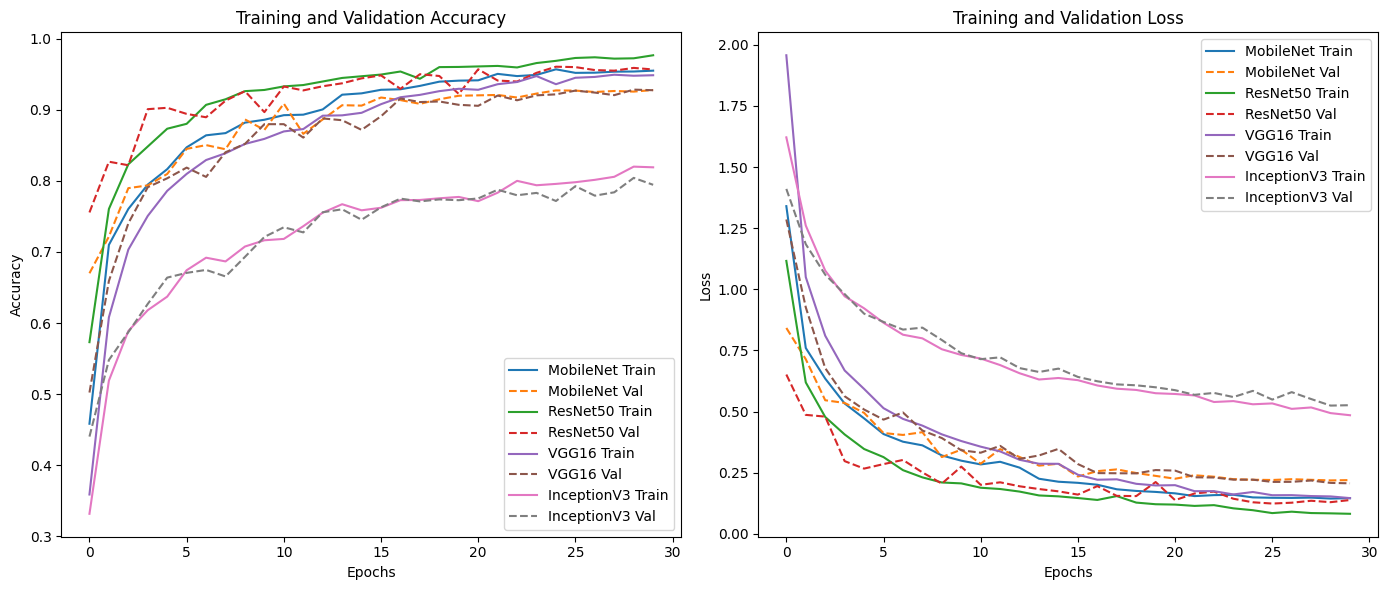

In [8]:
import matplotlib.pyplot as plt

# Define the number of epochs for plotting (minimum across all models)
min_epochs = min([len(acc_dict[name]) for name in model_names])

plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
for name in model_names:
    plt.plot(range(min_epochs), acc_dict[name][:min_epochs], label=f'{name} Train')
    plt.plot(range(min_epochs), val_acc_dict[name][:min_epochs], linestyle='--', label=f'{name} Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
for name in model_names:
    plt.plot(range(min_epochs), loss_dict[name][:min_epochs], label=f'{name} Train')
    plt.plot(range(min_epochs), val_loss_dict[name][:min_epochs], linestyle='--', label=f'{name} Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


#6. Comparing Test Performance

In [10]:
test_results = {}

for name in model_names:
    print(f"\nModel being evaluated: {name}")
    model = models_dict[name]
    test_datagen = data_generators[name][2]  # Get the corresponding test data generator


    # Make sure the test data generator is not out of order
    test_generator = test_datagen.flow_from_directory(
        '/content/dataset/Mosquito-on-human-skin/data_splitting/Test',
        batch_size=64,
        class_mode='categorical',
        target_size=(224, 224),
        shuffle=False
    )

    loss, accuracy = model.evaluate(test_generator, verbose=0)
    test_results[name] = {'Loss': loss, 'Accuracy': accuracy}
    print(f"{name} Test set loss: {loss:.4f}, Test set accuracy: {accuracy:.4f}")

# Convert to data frame for display
df_results = pd.DataFrame(test_results).T
df_results = df_results[['Loss', 'Accuracy']]
print("\nTest performance comparison:")
display(df_results)




Model being evaluated: MobileNet
Found 1799 images belonging to 6 classes.
MobileNet Test set loss: 0.3092, Test set accuracy: 0.8877

Model being evaluated: ResNet50
Found 1799 images belonging to 6 classes.
ResNet50 Test set loss: 0.2109, Test set accuracy: 0.9366

Model being evaluated: VGG16
Found 1799 images belonging to 6 classes.
VGG16 Test set loss: 0.2680, Test set accuracy: 0.9177

Model being evaluated: InceptionV3
Found 1799 images belonging to 6 classes.
InceptionV3 Test set loss: 0.6060, Test set accuracy: 0.7621

Test performance comparison:


,Loss,Accuracy
MobileNet,0.309161,0.887715
ResNet50,0.210896,0.936631
VGG16,0.267972,0.917732
InceptionV3,0.606007,0.762090


#7. Visualizing Test Performance

<ipython-input-11-3c1968cf9a41>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y='Accuracy', data=df_results, palette='viridis')


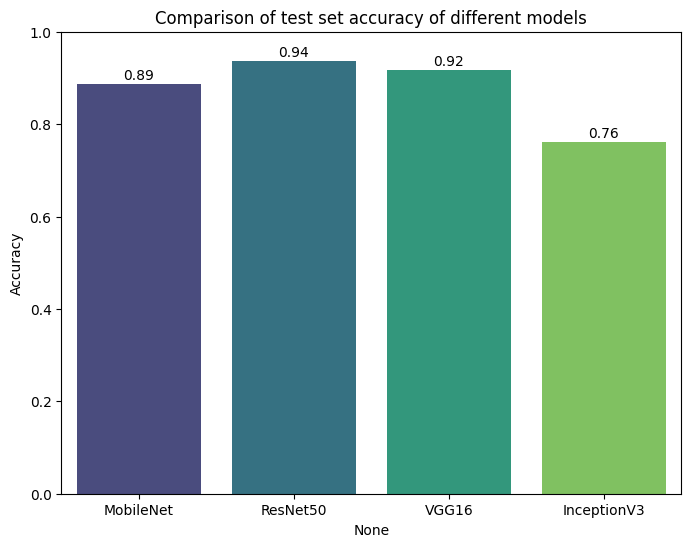

In [11]:
plt.figure(figsize=(8,6))
sns.barplot(x=df_results.index, y='Accuracy', data=df_results, palette='viridis')
plt.title('Comparison of test set accuracy of different models')
plt.ylabel('Accuracy')
plt.ylim(0,1)
for index, value in enumerate(df_results['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center')
plt.show()


# 8.Confusion matrix and classification report




MobileNet The results of the evaluation:
Found 1799 images belonging to 6 classes.


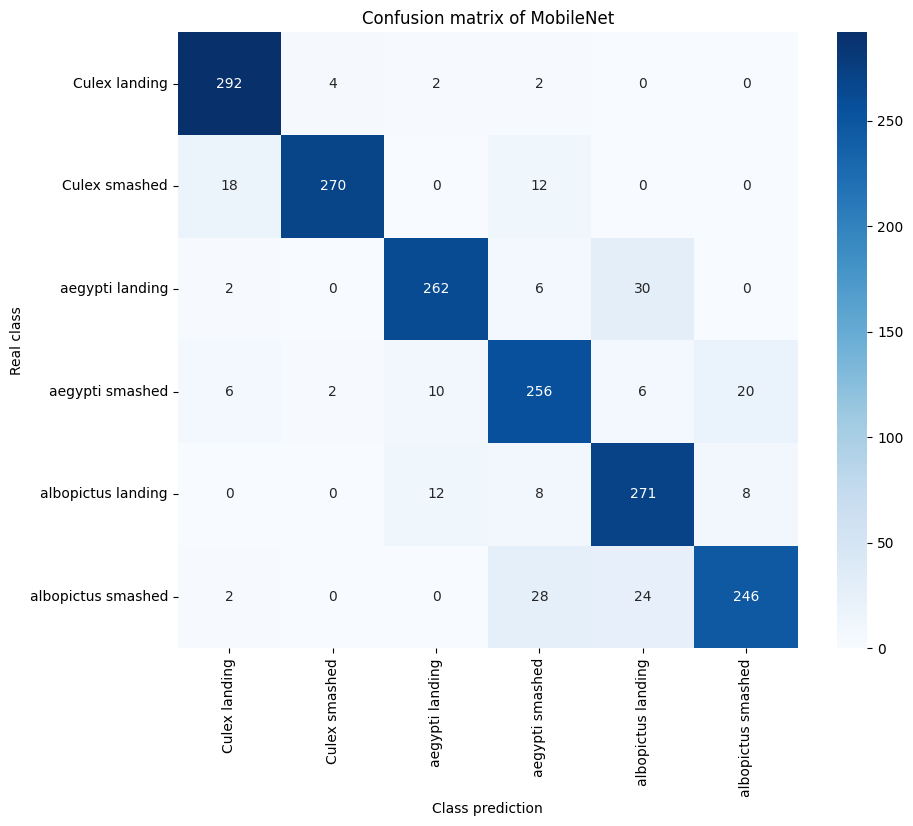

MobileNet Category report:
                    precision    recall  f1-score   support

     Culex landing       0.91      0.97      0.94       300
     Culex smashed       0.98      0.90      0.94       300
   aegypti landing       0.92      0.87      0.89       300
   aegypti smashed       0.82      0.85      0.84       300
albopictus landing       0.82      0.91      0.86       299
albopictus smashed       0.90      0.82      0.86       300

          accuracy                           0.89      1799
         macro avg       0.89      0.89      0.89      1799
      weighted avg       0.89      0.89      0.89      1799


ResNet50 The results of the evaluation:
Found 1799 images belonging to 6 classes.


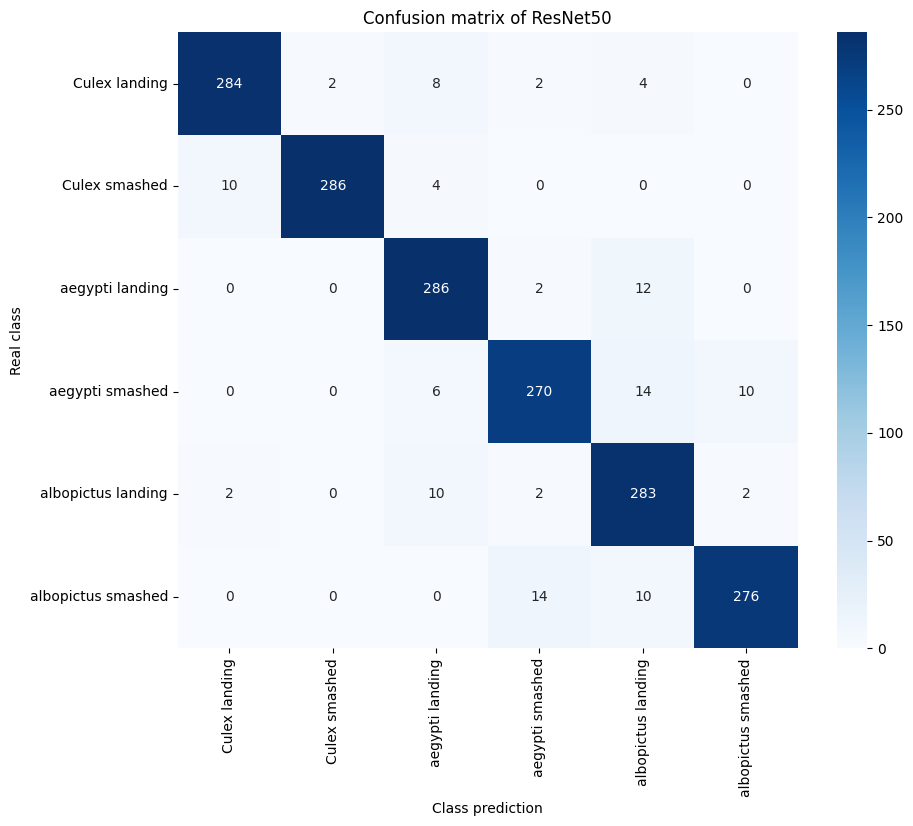

ResNet50 Category report:
                    precision    recall  f1-score   support

     Culex landing       0.96      0.95      0.95       300
     Culex smashed       0.99      0.95      0.97       300
   aegypti landing       0.91      0.95      0.93       300
   aegypti smashed       0.93      0.90      0.92       300
albopictus landing       0.88      0.95      0.91       299
albopictus smashed       0.96      0.92      0.94       300

          accuracy                           0.94      1799
         macro avg       0.94      0.94      0.94      1799
      weighted avg       0.94      0.94      0.94      1799


VGG16 The results of the evaluation:
Found 1799 images belonging to 6 classes.


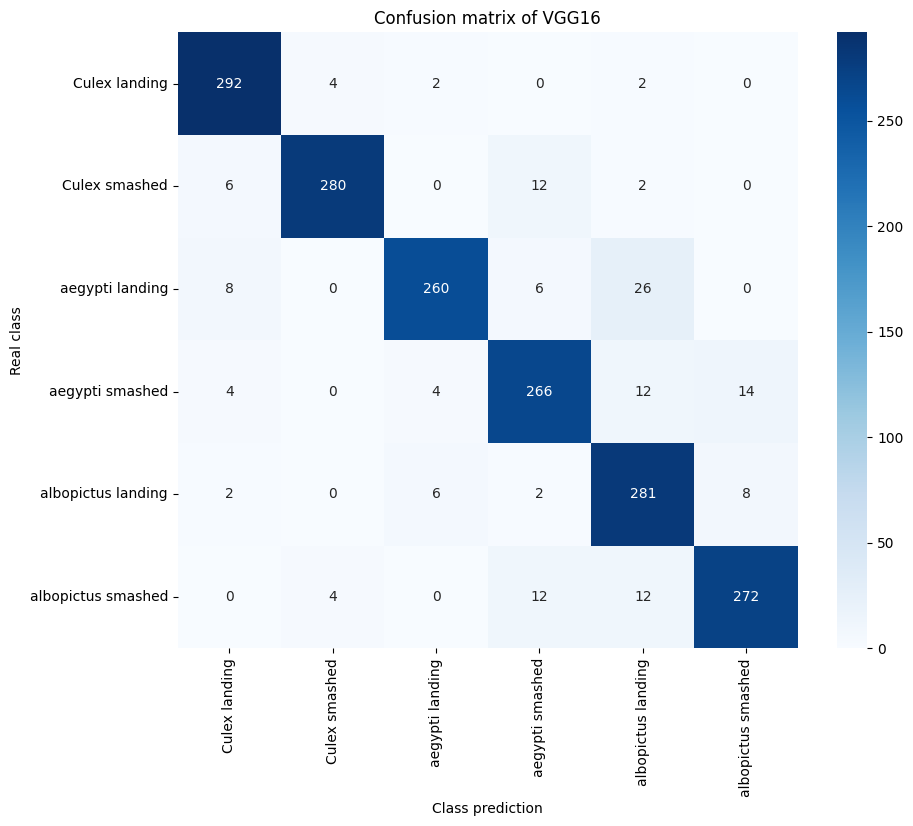

VGG16 Category report:
                    precision    recall  f1-score   support

     Culex landing       0.94      0.97      0.95       300
     Culex smashed       0.97      0.93      0.95       300
   aegypti landing       0.96      0.87      0.91       300
   aegypti smashed       0.89      0.89      0.89       300
albopictus landing       0.84      0.94      0.89       299
albopictus smashed       0.93      0.91      0.92       300

          accuracy                           0.92      1799
         macro avg       0.92      0.92      0.92      1799
      weighted avg       0.92      0.92      0.92      1799


InceptionV3 The results of the evaluation:
Found 1799 images belonging to 6 classes.


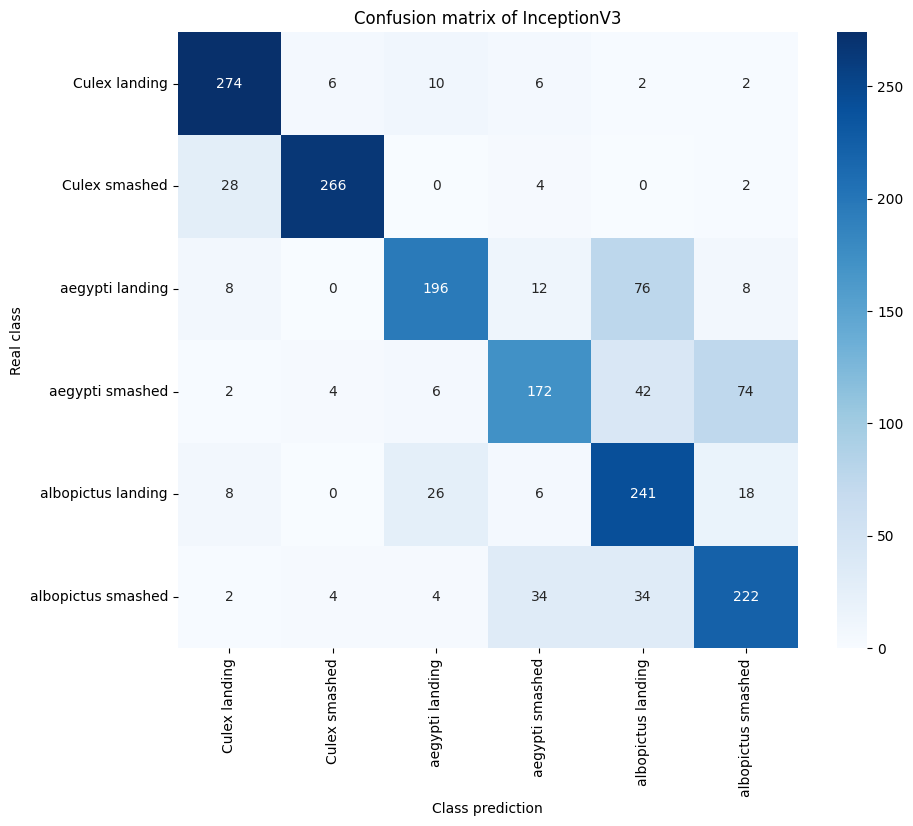

InceptionV3 Category report:
                    precision    recall  f1-score   support

     Culex landing       0.85      0.91      0.88       300
     Culex smashed       0.95      0.89      0.92       300
   aegypti landing       0.81      0.65      0.72       300
   aegypti smashed       0.74      0.57      0.64       300
albopictus landing       0.61      0.81      0.69       299
albopictus smashed       0.68      0.74      0.71       300

          accuracy                           0.76      1799
         macro avg       0.77      0.76      0.76      1799
      weighted avg       0.77      0.76      0.76      1799



In [12]:
def plot_confusion_matrix(model, data_gen, model_name):
    Y_true = data_gen.classes
    class_labels = list(data_gen.class_indices.keys())

    # prediction probability
    Y_pred_prob = model.predict(data_gen, verbose=0)
    Y_pred = np.argmax(Y_pred_prob, axis=1)

    # Computational confusion matrix
    cm = confusion_matrix(Y_true, Y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
    plt.xlabel('Class prediction')
    plt.ylabel('Real class')
    plt.title(f'Confusion matrix of {model_name}')
    plt.show()

    # Print classification report
    print(f"{model_name} Category report:")
    print(classification_report(Y_true, Y_pred, target_names=class_labels))

# Draw confusion matrices and classification reports for all models
for name in model_names:
    print(f"\n{name} The results of the evaluation:")
    test_datagen = data_generators[name][2]  # Get the corresponding test data generator
    test_generator = test_datagen.flow_from_directory(
        '/content/dataset/Mosquito-on-human-skin/data_splitting/Test',
        batch_size=64,
        class_mode='categorical',
        target_size=(224, 224),
        shuffle=False
    )
    plot_confusion_matrix(models_dict[name], test_generator, name)
